In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
#sns.set_theme(style="whitegrid")

In [2]:
# Cargamos el archivo
df = pd.read_csv('housing.csv')

#Lee las primeras filas del archivo tal cual
df.head()

#Ver columnas
#df.info()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Distribución de precios.

Detectar sesgo y explicarlo.

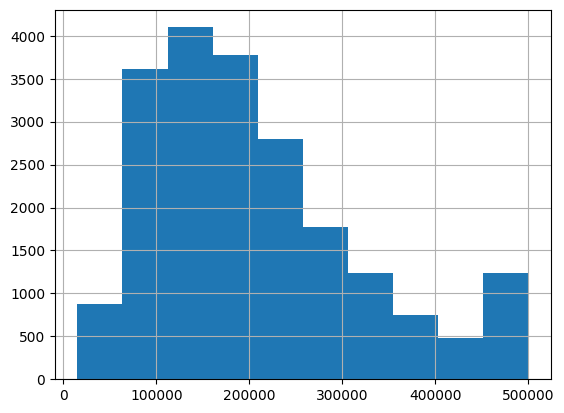

In [4]:
df["median_house_value"].hist()
plt.show()

Conclusión.
Se visualiza por la distribución que hay la presencia de outliers, se observa como por encima de aprox 450k hay una presencia significativa de casas con valores entre 405k y 500k esto nos permite sospechar de la presencia de outliers.
Este tipo de gráficos es adecuado ya que nos permite ver por distribuciones los precios y en base a un análisis contextual y razonamiento se puede considerar la presencia de un sesgo.

## Relación Ingreso/Precio

Crear un scatter entre ingreso medio y valor medio de casas y explicar si es positiva o negativa

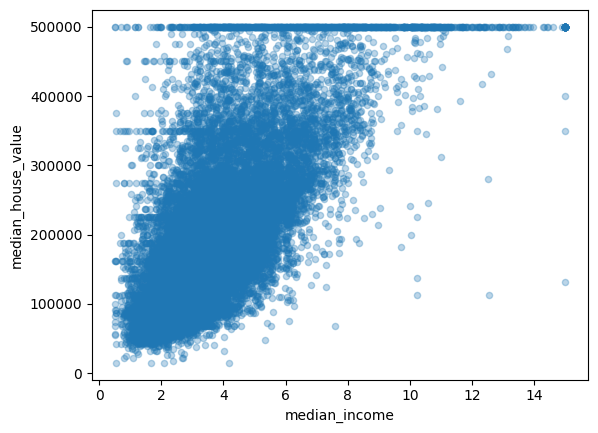

In [8]:
df.plot(
    kind="scatter",
    x="median_income",
    y="median_house_value",
    alpha=0.3
)
plt.show()

Conclusion. Se observa por el scatter que la relación es ascendente y se considera como positiva. Se debe de tener en cuenta que de forma aislada este análisis no puede afirmar o demostrar causalidad sin considerar otros factores a analisar.

## Comparar precios por cercanía al oceano.

Agrupar por proximidad al oceano y comparar precios promedio. Luego graficar boxplot.

In [11]:
#Visualizamos el promedio por categoría.
df.groupby("ocean_proximity")["median_house_value"].mean().sort_values(ascending=False)


ocean_proximity
ISLAND        380440.000000
NEAR BAY      259212.311790
NEAR OCEAN    249433.977427
<1H OCEAN     240084.285464
INLAND        124805.392001
Name: median_house_value, dtype: float64

Se observa que la categoría ISLAND tiene un promedio de precio más alto que las demás categorías.

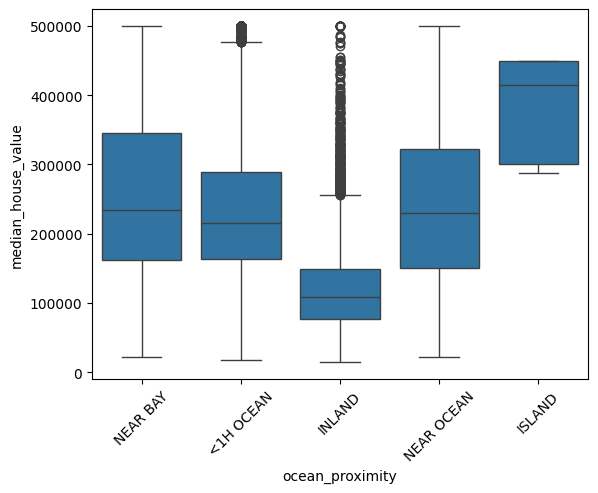

In [8]:
sns.boxplot(
    data=df,
    x="ocean_proximity",
    y="median_house_value"
)
plt.xticks(rotation=45)
plt.show()

Conclusión. En el boxplot, observamos que ISLAND la mediana más alta, la mediana es menos suceptible a cambios por valores extremos que la media/promedio. Tambien podemos observar que la categoría INLAND tiene presencia de outliers, dato que se sospechaba en el análisis con el histograma.
El boxplot trabaja con mediana y caja, bigotes de gatos y muestra outliers, nos da más info y más segura (a diferencia de promedio tenemos mediana)

---

## Dataset brasil.

Análisis previo

In [14]:
# Cargamos el archivo
df_brasil = pd.read_excel('datos_energia_bra.xlsx')

In [15]:
df_brasil.head()

,Data,TipoConsumidor,Sistema,UF,Setor Econômico - N1,Setor Econômico - N2,Setor Econômico - N3,Tipo Tensão - N1,Tipo Tensão - N2,Tipo Tensão - N3,Faixa de Consumo N1,Faixa de Consumo N2,Consumidores,Consumo
0,20140101,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,8.0
1,20140201,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,8.0
2,20140301,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,9.0
3,20140401,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,10.0
4,20140501,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,9.0


In [19]:
df_brasil.info()

<class 'pandas.DataFrame'>
RangeIndex: 285499 entries, 0 to 285498
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Data                  285499 non-null  int64  
 1   TipoConsumidor        285499 non-null  str    
 2   Sistema               285499 non-null  str    
 3   UF                    285499 non-null  str    
 4   Setor Econômico - N1  285499 non-null  str    
 5   Setor Econômico - N2  285499 non-null  str    
 6   Setor Econômico - N3  285499 non-null  str    
 7   Tipo Tensão - N1      285499 non-null  str    
 8   Tipo Tensão - N2      285499 non-null  str    
 9   Tipo Tensão - N3      285499 non-null  str    
 10  Faixa de Consumo N1   285499 non-null  str    
 11  Faixa de Consumo N2   285499 non-null  str    
 12  Consumidores          281511 non-null  float64
 13  Consumo               275799 non-null  float64
dtypes: float64(2), int64(1), str(11)
memory usage: 30.5 MB


In [34]:
df_brasil.isnull().sum()

Data                    0
TipoConsumidor          0
Sistema                 0
UF                      0
Setor Econômico - N1    0
Setor Econômico - N2    0
Setor Econômico - N3    0
Tipo Tensão - N1        0
Tipo Tensão - N2        0
Tipo Tensão - N3        0
Faixa de Consumo N1     0
Faixa de Consumo N2     0
Consumidores            0
Consumo                 0
Año                     0
dtype: int64

Consumo total por año.
Verificar columna de fecha para poder realizar el analásis y graficarlo.

In [33]:
df_brasil['Consumo'] = df_brasil['Consumo'].fillna(
    df_brasil['Consumo'].median()
)

df_brasil['Consumidores'] = df_brasil['Consumidores'].fillna(
    df_brasil['Consumidores'].median()
)

In [35]:
#Convertimos a tipo datetime
df_brasil["Data"] = pd.to_datetime(
    df_brasil["Data"],
    format="%Y%m%d"
)
#Nueva columna con dato de año
df_brasil['Año'] = df_brasil['Data'].dt.year

In [36]:
consumo_anual = df_brasil.groupby("Año")["Consumo"].sum().reset_index()
print(consumo_anual.sort_values(by='Año', ascending=False))

    Año       Consumo
9  2023  5.331302e+08
8  2022  5.106758e+08
7  2021  5.039699e+08
6  2020  4.777716e+08
5  2019  4.840017e+08
4  2018  4.773448e+08
3  2017  4.694200e+08
2  2016  4.637679e+08
1  2015  4.675495e+08
0  2014  4.763346e+08


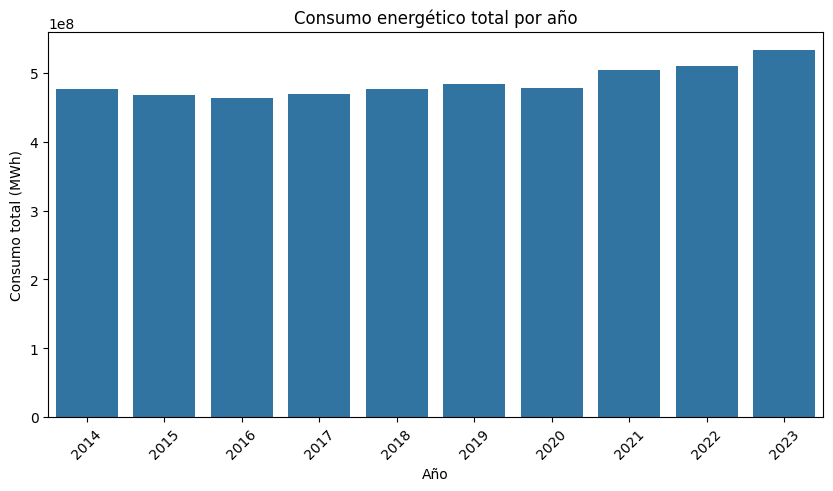

In [37]:
plt.figure(figsize=(10,5))
sns.barplot(data=consumo_anual, x="Año", y="Consumo")

plt.title("Consumo energético total por año")
plt.xlabel("Año")
plt.ylabel("Consumo total (MWh)")
plt.xticks(rotation=45)

plt.show()

Conclusión. Analizar y visualizar le consumo por año nos permite tener un panorama general del consumo, ya que normalmente el consumo de energía se mide por mes, nosotros lo agrupamos por año y podemos tener una vista aérea del consumo. Tambien considerar de que como el consumo es por periodos de meses, no debería de haber una diferencia muy grande de consumo por años y si lo hay se deriva a otro análisis donde se deben de considerar fuentes externas que aporten a la hipótesis.

## Consumo por sistema eléctrico

Calcular el consumo total por sistema y graficarlo ordenado de mayor a menor.

In [ ]:
#Se crea grupo por sistema, se ordena datos.
consumo_sistema = df_brasil.groupby("Sistema")["Consumo"].sum().sort_values(ascending=False).reset_index()

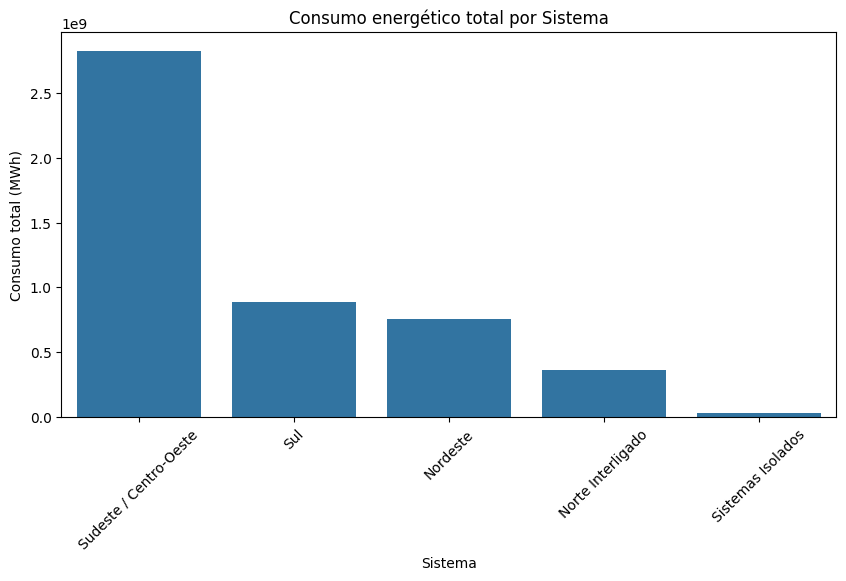

In [40]:
plt.figure(figsize=(10,5))
sns.barplot(data=consumo_sistema, x="Sistema", y="Consumo")

plt.title("Consumo energético total por Sistema")
plt.xlabel("Sistema")
plt.ylabel("Consumo total (MWh)")
plt.xticks(rotation=45)

plt.show()

Conclusión. Segmentar por sistema puede mostrar información útil como poder visualizar que sistema está mas cargado en el sistema nacional interconectado y los sistemas aislados. En resumen podemos comenzar a tomar una dirección en base a los datos de que sistema puede ser más conveniente aprovechar.

## Comprar UF entre dos años

Selecciona una UF, filtra dos años distintos y compara su consumo mensual.

In [44]:
#Nueva columna con dato de mes
df_brasil['Mes'] = df_brasil['Data'].dt.month

#Listamos y seleccionamos una uf
ver_uf = df_brasil.groupby('UF').size()
print(ver_uf)

UF
AC    11698
AL     7988
AM     7962
AP     7714
BA    13607
CE     9685
DF     5601
ES     7662
GO    11852
MA     5495
MG    12995
MS    10179
MT    12576
PA    17638
PB     8935
PE    14729
PI     7967
PR    14736
RJ    14427
RN     9685
RO    11968
RR     5243
RS    13268
SC     9758
SE     8897
SP    14151
TO     9083
dtype: int64


In [48]:
#Creamos un dataframe con el UF y los dos años seleccionados.
#Se selecciona las columanas a filtrar con condiciones
df_filtrado = df_brasil[
    (df_brasil['UF'] == 'AL') &
    (df_brasil['Año'].isin([2022,2023]))
]

In [50]:
#Realizamos la comparación de años y mes x consumo.
comparación = (
    df_filtrado
    .groupby(['Año', 'Mes'])['Consumo']
    .sum()
    .reset_index()
)

print(comparación)

     Año  Mes     Consumo
0   2022    1  430655.264
1   2022    2  436219.520
2   2022    3  461674.279
3   2022    4  419526.758
4   2022    5  360711.621
5   2022    6  357398.174
6   2022    7  436764.754
7   2022    8  435106.525
8   2022    9  399140.802
9   2022   10  416988.062
10  2022   11  413624.333
11  2022   12  433521.752
12  2023    1  473756.617
13  2023    2  434451.121
14  2023    3  480214.099
15  2023    4  478574.162
16  2023    5  463836.974
17  2023    6  449025.970
18  2023    7  404103.496
19  2023    8  402624.325
20  2023    9  445982.715
21  2023   10  459780.140
22  2023   11  493825.716
23  2023   12  505506.899


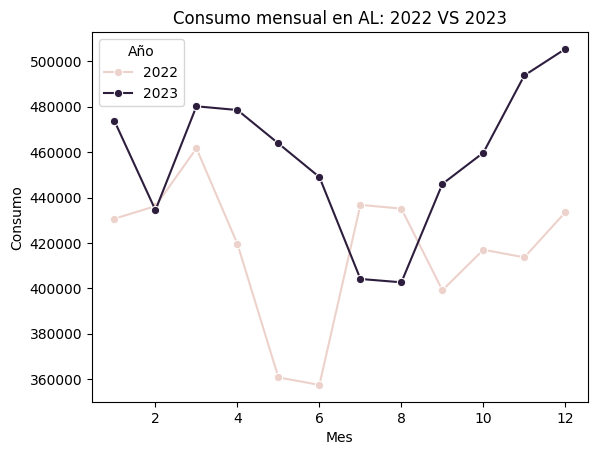

In [54]:
sns.lineplot(
    data=comparación,
    x='Mes',
    y='Consumo',
    hue='Año',
    marker='o'
)

plt.title('Consumo mensual en AL: 2022 VS 2023')
plt.show()

Conclusión. Se observa diferencias de consumo por mes entre los años seleccionados, no se explora causas ya que no tenemos fuentes externas oficiales relacionadas. Es mejor utilizar lineplot ya que se adapta y representa mejor cuando queremos graficar una línea a través del tiempo, mientras que barplot en este contexto sería más parecido a un histograma.